In [98]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import butter, filtfilt


# Tidsdomene av data

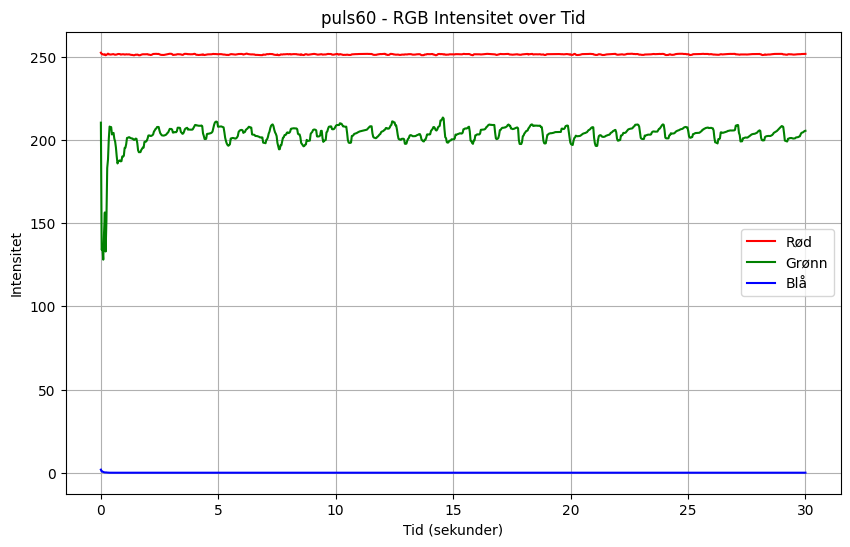

In [107]:
# Importer data fra tekstfilen
navn_fil = 'puls60' 
data = np.loadtxt(f"Txt_målinger/{navn_fil}", delimiter=' ')

# Del opp kolonnene
red = data[:, 0]
green = data[:, 1]
blue = data[:, 2]

lenge = np.linspace(0, 30, len(red))

plt.figure(figsize=(10, 6))
plt.plot(lenge, red, label='Rød', color='red')
plt.plot(lenge, green, label='Grønn', color='green')
plt.plot(lenge, blue, label='Blå', color='blue')
plt.xlabel('Tid (sekunder)')
plt.ylabel('Intensitet')
plt.title(f'{navn_fil} - RGB Intensitet over Tid')
plt.legend()
plt.grid()

plt.savefig(f'Figurer/RGB "{navn_fil}".png')


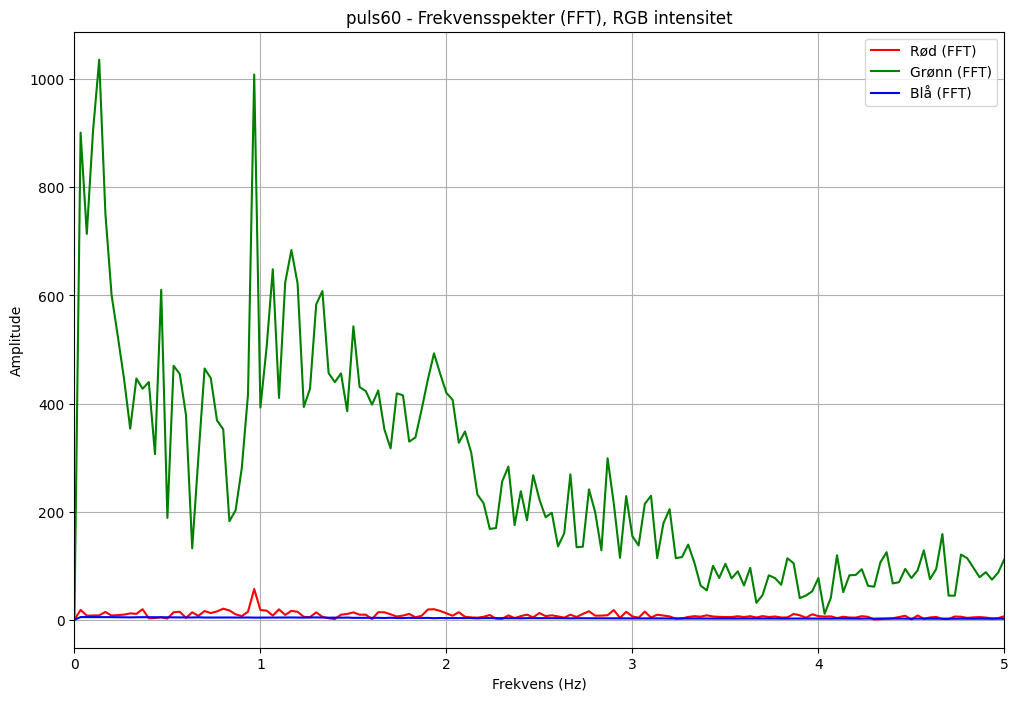

In [109]:

# Beregn FFT for hver kanal
N = len(red)  # Antall prøver
sample_period = 30 / N  # Samplingsperiode (total tid / antall prøver)
freq = np.fft.fftfreq(N, d=sample_period)  # Frekvensaksen


red_mean = np.mean(red)
green_mean = np.mean(green)
blue_mean = np.mean(blue)

rød = red - red_mean
grønn = green - green_mean
blå = blue - blue_mean

fft_red = np.fft.fft(rød)
fft_green = np.fft.fft(grønn)
fft_blue = np.fft.fft(blå)

# Ta absoluttverdien for å få størrelsen på frekvenskomponentene
magnitude_red = np.abs(fft_red)
magnitude_green = np.abs(fft_green)
magnitude_blue = np.abs(fft_blue)


# Plot frekvensspekteret
plt.figure(figsize=(12, 8))
plt.plot(freq[:N // 2], magnitude_red[:N // 2], label='Rød (FFT)', color='red')
plt.plot(freq[:N // 2], magnitude_green[:N // 2], label='Grønn (FFT)', color='green')
plt.plot(freq[:N // 2], magnitude_blue[:N // 2], label='Blå (FFT)', color='blue')
plt.xlabel('Frekvens (Hz)')
plt.ylabel('Amplitude')
plt.title(f'{navn_fil} - Frekvensspekter (FFT), RGB intensitet')
plt.xlim(0, 5)  # Begrens x-aksen til 0-5 Hz for bedre visning
plt.legend()
plt.grid()
plt.show

plt.savefig(f'Figurer/FFT "{navn_fil}" - ufiltrert.png')

# MED FILTER

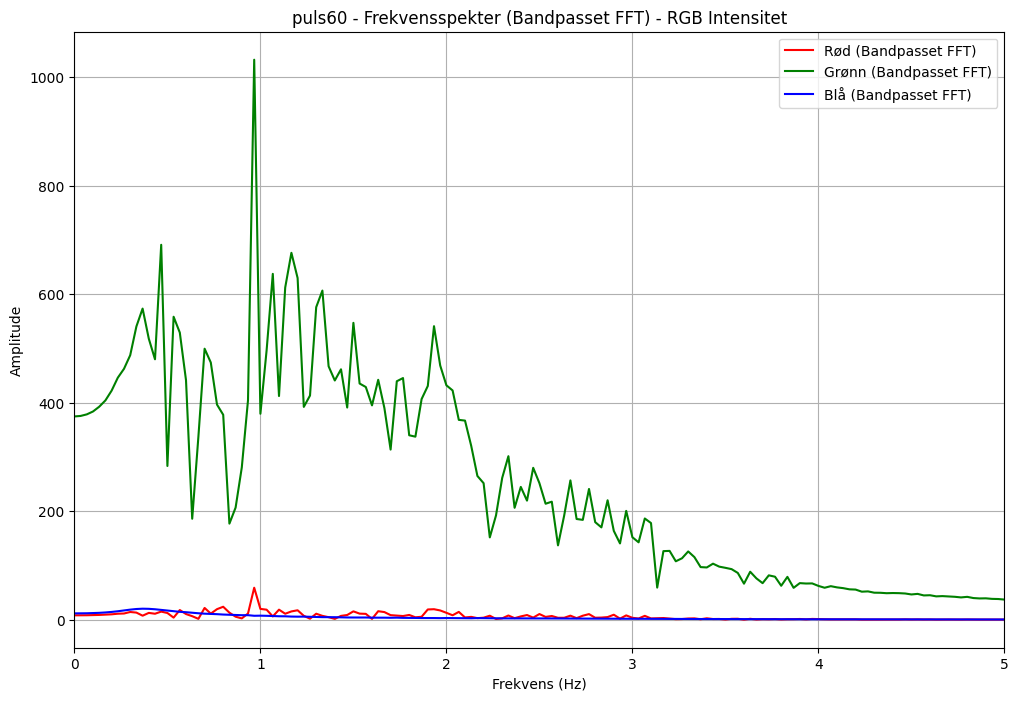

In [101]:
fs = 40
nedre_grense = 0.5
øvre_grense = 4.0
b, a = butter(3, [nedre_grense/(fs/2) , øvre_grense/(fs/2)], btype='band')  

filtered_red = filtfilt(b, a, rød)
filtered_green = filtfilt(b, a, grønn)
filtered_blue = filtfilt(b, a, blå)

fft_filtered_red = np.fft.fft(filtered_red)
fft_filtered_green = np.fft.fft(filtered_green)
fft_filtered_blue = np.fft.fft(filtered_blue)

magnitude_filtered_red = np.abs(fft_filtered_red)
magnitude_filtered_green = np.abs(fft_filtered_green)
magnitude_filtered_blue = np.abs(fft_filtered_blue)

plt.figure(figsize=(12, 8))
plt.plot(freq[:N // 2], magnitude_filtered_red[:N // 2], label='Rød (Bandpasset FFT)', color='red')
plt.plot(freq[:N // 2], magnitude_filtered_green[:N // 2], label='Grønn (Bandpasset FFT)', color='green')
plt.plot(freq[:N // 2], magnitude_filtered_blue[:N // 2], label='Blå (Bandpasset FFT)', color='blue')
plt.xlabel('Frekvens (Hz)')
plt.ylabel('Amplitude')
plt.title(f'{navn_fil} - Frekvensspekter (Bandpasset FFT) - RGB Intensitet')
plt.xlim(0, 5)  # Begrens x-aksen til 0-5 Hz for bedre visning
plt.legend()
plt.grid()
plt.show()



# Finne puls

In [102]:
def finn_pulsfrekvens(magnitude, freq):
    relevant_indices = np.where((freq >= nedre_grense) & (freq <= øvre_grense))
    relevant_magnitude = magnitude[relevant_indices]
    relevant_freq = freq[relevant_indices]

    if len(relevant_magnitude) == 0:
        return None  # Ingen relevante frekvenser funnet

    max_index = np.argmax(relevant_magnitude)
    pulsfrekvens = relevant_freq[max_index]
    
    return pulsfrekvens * 60  # Konverter fra Hz til BPM

pulsfrekvens_red = finn_pulsfrekvens(magnitude_filtered_red, freq)
pulsfrekvens_green = finn_pulsfrekvens(magnitude_filtered_green, freq)
pulsfrekvens_blue = finn_pulsfrekvens(magnitude_filtered_blue, freq)
print(f"Pulsfrekvens (Rød): {pulsfrekvens_red:.2f} BPM")
print(f"Pulsfrekvens (Grønn): {pulsfrekvens_green:.2f} BPM")
print(f"Pulsfrekvens (Blå): {pulsfrekvens_blue:.2f} BPM")



Pulsfrekvens (Rød): 58.00 BPM
Pulsfrekvens (Grønn): 58.00 BPM
Pulsfrekvens (Blå): 30.00 BPM


# SISTE FIGUR

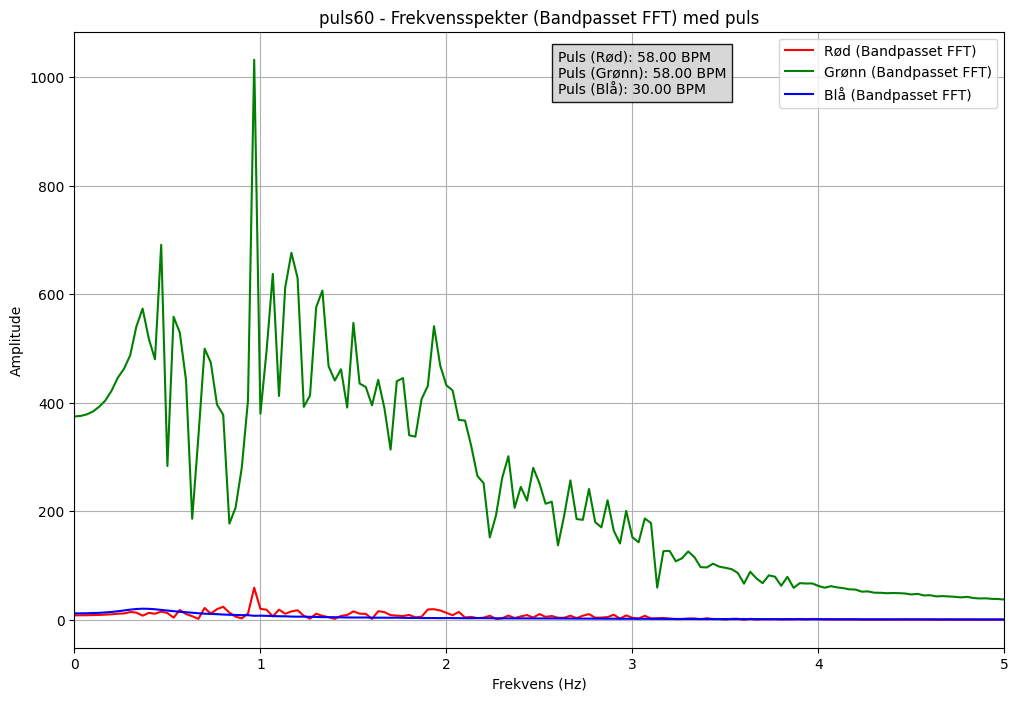

In [110]:
plt.figure(figsize=(12, 8))
plt.plot(freq[:N // 2], magnitude_filtered_red[:N // 2], label='Rød (Bandpasset FFT)', color='red')
plt.plot(freq[:N // 2], magnitude_filtered_green[:N // 2], label='Grønn (Bandpasset FFT)', color='green')
plt.plot(freq[:N // 2], magnitude_filtered_blue[:N // 2], label='Blå (Bandpasset FFT)', color='blue')
plt.xlabel('Frekvens (Hz)')
plt.ylabel('Amplitude')
plt.title(f'{navn_fil} - Frekvensspekter (Bandpasset FFT) med puls')
pulse_text = (
    f"Puls (Rød): {pulsfrekvens_red:.2f} BPM\n"
    f"Puls (Grønn): {pulsfrekvens_green:.2f} BPM\n"
    f"Puls (Blå): {pulsfrekvens_blue:.2f} BPM"
)
plt.text(2.6, 970, pulse_text, fontsize=10, bbox=dict(facecolor='lightgrey', alpha=0.9))
plt.xlim(0, 5)  # Begrens x-aksen til 0-5 Hz for bedre visning
plt.legend()
plt.grid()
plt.savefig(f'Figurer/FFT & Puls "{navn_fil}" - bandpasset.png')
plt.show()


